# Newton Ring Extraction
When the stage is close to the sample (low z), a **Newton ring** (an interference ring) becomes
visible in the frame. Since z itself carries no reliable signal in the raw pixels (frame diffs show
no coherent structure for Δz), we extract the ring instead — its **area** shrinks/grows and its
**centroid** shifts as z changes.

This notebook, given an HDF5 file (`frame_i_x` uint8 BGR frames), extracts per-frame:
- `area` — pixel area of the thresholded ring contour
- `cx, cy` — centroid of the ring contour (pixel coordinates)

These are meant to feed a downstream model's target vector as
`[Δx, Δy, Δcircle_center_x, Δcircle_center_y, Δcircle_area]` instead of raw `Δz`.

**Method**: grayscale + Otsu's threshold (automatic, ignores color entirely — just splits the image
into two intensity classes), clean up with morphological open/close, take the largest contour,
compute its area and centroid via image moments.

### Imports

In [1]:
import re

import cv2
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path.cwd().parent / '20X_DropDown' if Path.cwd().name == 'data_construction' else Path('20X_DropDown')

## Config
Pick the HDF5 file and a frame to tune thresholds on. Prefer a frame where z is low (ring clearly
visible) for tuning.

3/20x.hdf5 has 1931 frames
frame 250  shape=(224, 224, 3)  position(xyz)=[5.915027 4.93497  5.06271 ]


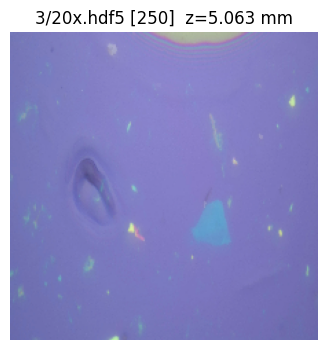

In [90]:
ref_frames = [0, 0, 0, 0, 0]   # ref_frames[i] = frame index to subtract by for robot_{i+1}.hdf5

H5_NAME    = '3/20x.hdf5'
TUNE_FRAME = 250

def load_frame(data_dir: Path, h5_name: str, idx: int):
    path = data_dir / h5_name
    with h5py.File(path, 'r') as f:
        frame_bgr = f[f'frame_{idx}_x'][:]
        position  = f[f'frame_{idx}_y'][:].astype(np.float32)
    return frame_bgr[:, :, ::-1], position   # BGR -> RGB


def num_frames(data_dir: Path, h5_name: str) -> int:
    with h5py.File(data_dir / h5_name, 'r') as f:
        return sum(1 for k in f.keys() if k.endswith('_x'))


def ref_frame_idx_for(h5_name: str) -> int:
    """robot_N.hdf5 -> ref_frames[N - 1]."""
    file_num = int(re.search(r'(\d+)', h5_name).group(1))
    return ref_frames[file_num - 1]


frame, pos = load_frame(DATA_DIR, H5_NAME, TUNE_FRAME)
print(f'{H5_NAME} has {num_frames(DATA_DIR, H5_NAME)} frames')
print(f'frame {TUNE_FRAME}  shape={frame.shape}  position(xyz)={pos}')

plt.figure(figsize=(4, 4))
plt.imshow(frame)
plt.title(f'{H5_NAME} [{TUNE_FRAME}]  z={pos[2]:.3f} mm')
plt.axis('off')
plt.show()

## Ring extraction
Otsu's automatic threshold gets pulled toward whatever population of pixels dominates the image,
so when the ring is a small minority of pixels it often fails to isolate it. Instead, we convert
both the analyzed frame and **frame 0** (`REF_FRAME_IDX`) to **CIELAB** (via OpenCV), subtract, and
take the per-pixel Lab-space Euclidean distance — Lab better separates genuine hue/chroma changes
(like the ring appearing) from lighting-only brightness shifts than a plain grayscale diff. We
threshold that distance at a fixed magnitude (`DIFF_THRESH`), take the largest contour, and accept
it only if its area clears `MIN_AREA`.

area=250.0 px^2   centroid=(137.2, 2.6) px


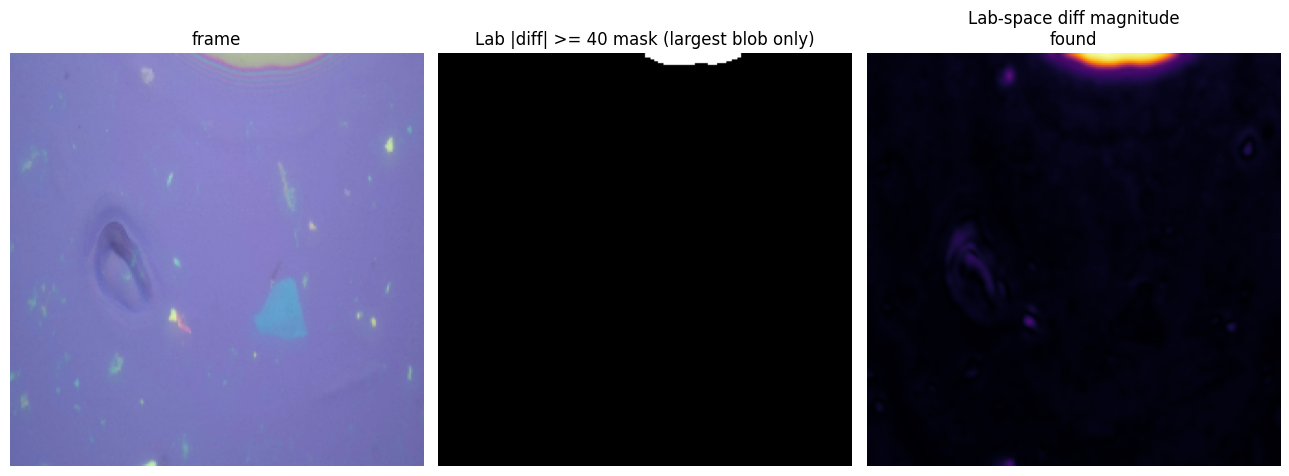

In [91]:
MIN_AREA     = 50.0   # contours smaller than this (in px^2) are treated as 'no ring found'
MORPH_KSIZE  = 5
BLUR_KSIZE   = 9      # odd kernel size for gaussian blur before diffing/thresholding (0 = no blur)
DIFF_THRESH  = 40      # pixels with ||Lab(frame) - Lab(ref)||_2 >= this are treated as foreground

REF_FRAME_IDX = ref_frame_idx_for(H5_NAME)
ref_frame, _  = load_frame(DATA_DIR, H5_NAME, REF_FRAME_IDX)


def extract_ring_features(frame_rgb: np.ndarray, ref_rgb: np.ndarray, min_area: float = MIN_AREA,
                           morph_ksize: int = MORPH_KSIZE, blur_ksize: int = BLUR_KSIZE,
                           diff_thresh: float = DIFF_THRESH):
    """Convert `frame_rgb` and `ref_rgb` (the file's own reference frame, per `ref_frames`) to
    CIELAB, subtract, and threshold the per-pixel Lab-space Euclidean distance at a fixed
    magnitude (`diff_thresh`) to find the ring's contour. Lab better separates the ring's
    hue/chroma shift from lighting-only changes than a plain grayscale diff. Only the single
    largest connected blob in the thresholded mask is kept — any other, smaller blobs are
    discarded from the returned mask.

    Always returns a dict with keys 'found', 'mask', 'diff', 'contour', 'area', 'cx', 'cy'.
    'mask' (containing only the largest blob, if any survived thresholding/morphology) and
    'diff' (and 'contour', when available) are returned regardless of whether a valid ring was
    found, so the caller can inspect why a rejection happened. When 'found' is False, a message
    describing which condition failed is printed and 'area'/'cx'/'cy' are None.
    """
    lab     = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    ref_lab = cv2.cvtColor(ref_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    if blur_ksize > 0:
        lab     = cv2.GaussianBlur(lab, (blur_ksize, blur_ksize), 0)
        ref_lab = cv2.GaussianBlur(ref_lab, (blur_ksize, blur_ksize), 0)

    diff = np.linalg.norm(lab - ref_lab, axis=-1)   # (H, W) Lab-space Euclidean distance per pixel
    diff_u8 = np.clip(diff, 0, 255).astype(np.uint8)

    _, raw_mask = cv2.threshold(diff_u8, diff_thresh, 255, cv2.THRESH_BINARY)

    kernel = np.ones((morph_ksize, morph_ksize), np.uint8)
    raw_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel)
    raw_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_CLOSE, kernel)

    empty = {'found': False, 'mask': raw_mask, 'diff': diff, 'contour': None, 'area': None,
              'cx': None, 'cy': None}

    contours, _ = cv2.findContours(raw_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        print('extract_ring_features: rejected — no contours found after thresholding/morphology')
        return empty

    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)

    # keep only the largest blob in the returned mask, discarding any other contours
    mask = np.zeros_like(raw_mask)
    cv2.drawContours(mask, [largest], -1, 255, thickness=cv2.FILLED)
    empty['mask'] = mask
    empty['contour'] = largest
    empty['area'] = float(area)
    if area < min_area:
        print(f'extract_ring_features: rejected — largest contour area {area:.1f} < MIN_AREA {min_area}')
        return empty

    M = cv2.moments(largest)
    if M['m00'] == 0:
        print('extract_ring_features: rejected — degenerate contour (zero moment, m00 == 0)')
        return empty
    cx = M['m10'] / M['m00']
    cy = M['m01'] / M['m00']

    return {'found': True, 'area': float(area), 'cx': float(cx), 'cy': float(cy), 'mask': mask,
            'diff': diff, 'contour': largest}


result = extract_ring_features(frame, ref_frame)
if not result['found']:
    print('No ring found on the tuning frame — no contour survived thresholding. Try adjusting '
          'DIFF_THRESH / BLUR_KSIZE / MIN_AREA.')
else:
    print(f"area={result['area']:.1f} px^2   centroid=({result['cx']:.1f}, {result['cy']:.1f}) px")

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
axes[0].imshow(frame)
axes[0].set_title('frame')
axes[0].axis('off')

axes[1].imshow(result['mask'], cmap='gray')
axes[1].set_title(f'Lab |diff| >= {DIFF_THRESH} mask (largest blob only)')
axes[1].axis('off')

axes[2].imshow(result['diff'], cmap='inferno')
axes[2].set_title(f"Lab-space diff magnitude\n{'found' if result['found'] else 'no ring found'}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Interactive tuning
Adjust `DIFF_THRESH` (fixed diff magnitude cutoff), blur amount, min area, and color tolerance
below (try changing `TUNE_FRAME` above and re-running if the ring isn't visible on the current
frame).

In [52]:
import ipywidgets as widgets
from IPython.display import display


def _preview(blur_ksize, diff_thresh, min_area):
    blur_ksize = blur_ksize if blur_ksize % 2 == 1 else blur_ksize + 1   # must be odd
    res = extract_ring_features(frame, ref_frame, blur_ksize=blur_ksize, diff_thresh=diff_thresh,
                                 min_area=min_area)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    axes[0].imshow(frame)
    axes[0].axis('off')
    axes[0].set_title('frame')

    axes[1].imshow(res['diff'], cmap='inferno')
    if res['found']:
        axes[1].set_title(f"Lab diff — area={res['area']:.0f} px^2  centroid=({res['cx']:.0f},{res['cy']:.0f})")
    else:
        axes[1].set_title('Lab diff — no ring found')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
    print(f'BLUR_KSIZE  = {blur_ksize}')
    print(f'DIFF_THRESH = {diff_thresh}')
    print(f'MIN_AREA    = {min_area}')


widgets.interact(
    _preview,
    blur_ksize=widgets.IntSlider(value=BLUR_KSIZE, min=0, max=25, step=2, description='blur k'),
    diff_thresh=widgets.IntSlider(value=DIFF_THRESH, min=0, max=255, step=5, description='diff thresh'),
    min_area=widgets.FloatSlider(value=MIN_AREA, min=0, max=2000, step=10, description='min area'),
)

print('\nOnce happy, copy the printed BLUR_KSIZE / DIFF_THRESH / MIN_AREA values into the cell above and re-run it.')

interactive(children=(IntSlider(value=9, description='blur k', max=25, step=2), IntSlider(value=60, descriptio…


Once happy, copy the printed BLUR_KSIZE / DIFF_THRESH / MIN_AREA values into the cell above and re-run it.


## Batch extraction over a whole episode
Runs the (tuned) extractor over every frame in `H5_NAME` and compares the extracted area/centroid
against the ground-truth z position, to sanity-check that they actually track z.

In [ ]:
n = num_frames(DATA_DIR, H5_NAME)

areas   = np.full(n, np.nan, dtype=np.float32)
cxs     = np.full(n, np.nan, dtype=np.float32)
cys     = np.full(n, np.nan, dtype=np.float32)
zs      = np.zeros(n, dtype=np.float32)
found   = np.zeros(n, dtype=bool)

with h5py.File(DATA_DIR / H5_NAME, 'r') as f:
    ref_bgr = f[f'frame_{REF_FRAME_IDX}_x'][:]
    ref_rgb = ref_bgr[:, :, ::-1]

    for i in range(n):
        bgr = f[f'frame_{i}_x'][:]
        rgb = bgr[:, :, ::-1]
        pos = f[f'frame_{i}_y'][:].astype(np.float32)
        zs[i] = pos[2]

        res = extract_ring_features(rgb, ref_rgb)
        if res['found']:
            areas[i] = res['area']
            cxs[i]   = res['cx']
            cys[i]   = res['cy']
            found[i] = True

print(f'Ring found in {found.sum()}/{n} frames ({100 * found.mean():.1f}%)')

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(zs, label='ground-truth z (mm)', color='tab:red')
axes[0].set_ylabel('z (mm)')
axes[0].legend(loc='upper right', fontsize=8)

axes[1].plot(areas, label='ring area (px²)', color='tab:blue')
axes[1].set_ylabel('area (px²)')
axes[1].legend(loc='upper right', fontsize=8)

axes[2].plot(cxs, label='centroid x (px)', color='tab:green')
axes[2].plot(cys, label='centroid y (px)', color='tab:orange')
axes[2].set_ylabel('centroid (px)')
axes[2].set_xlabel('frame index')
axes[2].legend(loc='upper right', fontsize=8)

plt.suptitle(f'{H5_NAME} — ring features vs. ground-truth z', fontsize=11)
plt.tight_layout()
plt.show()

valid = found
if valid.sum() > 1:
    corr_area = np.corrcoef(zs[valid], areas[valid])[0, 1]
    print(f'corr(z, area) = {corr_area:.3f}')

## Write ring features into each HDF5 file
For every `robot_*.hdf5` file in `DATA_DIR`, run the extractor over every frame and write a new
`frame_{n}_ring` dataset containing `[center_x, center_y, area]` (all `NaN` if no ring was found).
Uses `frame_0` as each file's own reference frame. Existing `frame_{n}_ring` keys are left
untouched — already-processed files/frames are skipped.

In [75]:
h5_paths = sorted(DATA_DIR.rglob('*.hdf5'))
print(f'Found {len(h5_paths)} HDF5 file(s) in {DATA_DIR}')

for h5_path in h5_paths:
    with h5py.File(h5_path, 'r+') as f:
        n = sum(1 for k in f.keys() if k.endswith('_x'))

        # ref_idx = ref_frame_idx_for(h5_path.name)
        ref_idx = 0
        ref_bgr = f[f'frame_{ref_idx}_x'][:]
        ref_rgb = ref_bgr[:, :, ::-1]

        written, skipped = 0, 0
        for i in range(n):
            ring_key = f'frame_{i}_ring'

            bgr = f[f'frame_{i}_x'][:]
            rgb = bgr[:, :, ::-1]
            res = extract_ring_features(rgb, ref_rgb)

            if res['found']:
                vec = np.array([res['cx'], res['cy'], res['area']], dtype=np.float32)
            else:
                vec = np.full(3, np.nan, dtype=np.float32)

            if ring_key in f:
                del f[ring_key]
            f.create_dataset(ring_key, data=vec)
            written += 1

        print(f'{h5_path.name}: ref_frame={ref_idx}  wrote {written} new frame_*_ring keys, skipped {skipped} existing')

Found 9 HDF5 file(s) in 20X_DropDown
extract_ring_features: rejected — no contours found after thresholding/morphology
extract_ring_features: rejected — no contours found after thresholding/morphology
extract_ring_features: rejected — no contours found after thresholding/morphology
extract_ring_features: rejected — no contours found after thresholding/morphology
extract_ring_features: rejected — no contours found after thresholding/morphology
extract_ring_features: rejected — no contours found after thresholding/morphology
extract_ring_features: rejected — no contours found after thresholding/morphology
extract_ring_features: rejected — no contours found after thresholding/morphology
extract_ring_features: rejected — no contours found after thresholding/morphology
extract_ring_features: rejected — no contours found after thresholding/morphology
extract_ring_features: rejected — no contours found after thresholding/morphology
extract_ring_features: rejected — no contours found after thr

## Plot z vs. ring area for a given file
Reads the stored `frame_{n}_y` (z-position) and `frame_{n}_ring` (`[cx, cy, area]`, written by the
cell above) datasets directly from a chosen HDF5 file and plots z-position on top and ring area on
the bottom.

501/1186 frames have no frame_*_ring key yet (plotted as gaps).


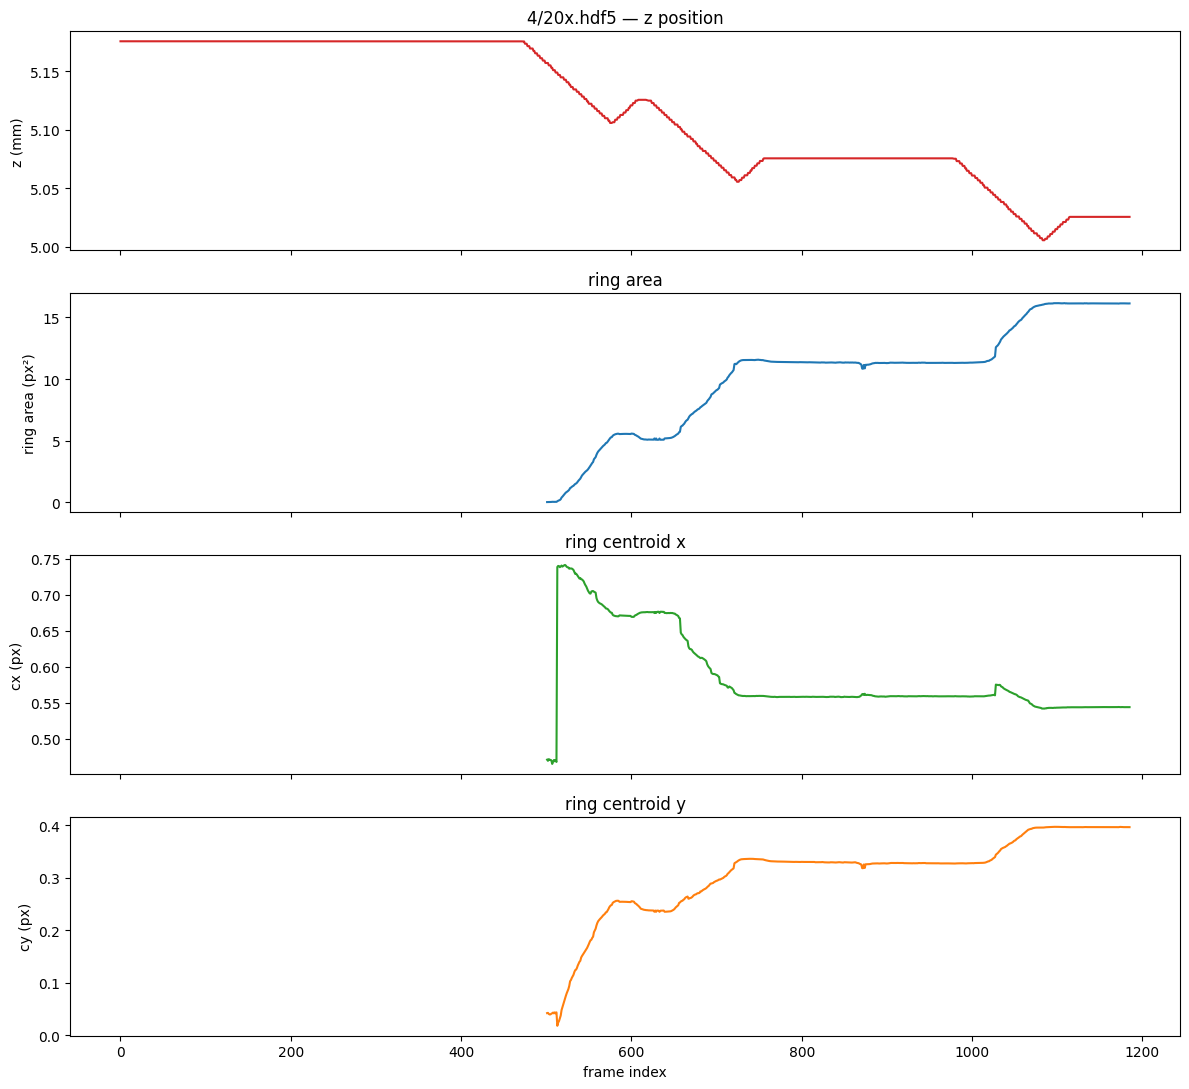

In [94]:
PLOT_H5_NAME = '4/20x.hdf5'

with h5py.File(DATA_DIR / PLOT_H5_NAME, 'r') as f:
    n = sum(1 for k in f.keys() if k.endswith('_x'))

    zs_plot   = np.zeros(n, dtype=np.float32)
    area_plot = np.full(n, np.nan, dtype=np.float32)
    cx_plot   = np.full(n, np.nan, dtype=np.float32)
    cy_plot   = np.full(n, np.nan, dtype=np.float32)

    for i in range(n):
        zs_plot[i] = f[f'frame_{i}_y'][:].astype(np.float32)[2]

        ring_key = f'frame_{i}_ring'
        if ring_key in f:
            ring_vec = f[ring_key][:]
            cx_plot[i]   = ring_vec[0]
            cy_plot[i]   = ring_vec[1]
            area_plot[i] = ring_vec[2]

missing = np.isnan(area_plot).sum()
if missing == n:
    print(f'No frame_*_ring keys found in {PLOT_H5_NAME} — run the "write ring features" cell above first.')
elif missing:
    print(f'{missing}/{n} frames have no frame_*_ring key yet (plotted as gaps).')

fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)

axes[0].plot(zs_plot, color='tab:red')
axes[0].set_ylabel('z (mm)')
axes[0].set_title(f'{PLOT_H5_NAME} — z position')

axes[1].plot(area_plot / (2e3), color='tab:blue')
axes[1].set_ylabel('ring area (px²)')
axes[1].set_title('ring area')

axes[2].plot(cx_plot/224, color='tab:green')
axes[2].set_ylabel('cx (px)')
axes[2].set_title('ring centroid x')

axes[3].plot(cy_plot/224, color='tab:orange')
axes[3].set_ylabel('cy (px)')
axes[3].set_xlabel('frame index')
axes[3].set_title('ring centroid y')

plt.tight_layout()
plt.show()

## Clear bad ring features for a frame range
Overwrites `frame_{n}_ring` with `[NaN, NaN, NaN]` (i.e. "not found") for a chosen file and frame
range, so bad extractions can be blanked out. Since `save_features` above skips frames that already
have a `frame_{n}_ring` key, re-running it afterwards will **not** recompute these — only use this
to permanently mark a range as invalid, or delete the keys (`del f[ring_key]`) below first if you
want `save_features` to re-extract them.

In [93]:
CLEAR_H5_NAME     = PLOT_H5_NAME
CLEAR_FRAME_START = 0
CLEAR_FRAME_END   = 450

with h5py.File(DATA_DIR / CLEAR_H5_NAME, 'r+') as f:
    cleared, missing = 0, 0
    for i in range(CLEAR_FRAME_START, CLEAR_FRAME_END + 1):
        ring_key = f'frame_{i}_ring'
        if ring_key not in f:
            missing += 1
            continue
        f[ring_key][...] = np.full(3, np.nan, dtype=np.float32)
        cleared += 1

    print(f'{CLEAR_H5_NAME}: cleared frame_{{{CLEAR_FRAME_START}..{CLEAR_FRAME_END}}}_ring -> NaN '
          f'({cleared} cleared, {missing} had no ring key)')

4/20x.hdf5: cleared frame_{0..450}_ring -> NaN (451 cleared, 0 had no ring key)
